In [1]:
import os
os.chdir('../../../../..')

In [23]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.tangentspace import TangentSpace
import umap
import matplotlib.ticker as mticker
import seaborn as sns
from loguru import logger
from sklearn.manifold import TSNE, MDS
import gc
import logging
from __future__ import annotations

import os
import sys
import warnings
from typing import Any, List, Optional, Sequence, Tuple

import numpy as np
import polars as pl
from loguru import logger
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold

# --- Utility Helpers ---
import time
from typing import Any, Dict, List, Sequence, Tuple
from ase import Atoms
from dscribe.descriptors import SOAP
import numpy as np
import polars as pl
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import TruncatedSVD
from tqdm import tqdm


# =============================================================================
# MAIN EXPERIMENT
# =============================================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.covariance import oas

import ot  
import persim
from dscribe.kernels import REMatchKernel
from ripser import ripser
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, PersistentHomology
from src.optimal_transport import REMatch
from src.helper_functions import create_chemiscope_viewer


In [3]:
qm9 = QM9Dataset(limit=25_000, descriptors=["soap"])
df = qm9.load()

2026-06-07 09:03:27.891 | INFO     | src.datasets:_load_full_qm9_df:846 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-07 09:03:28.340 | INFO     | src.datasets:_sample_qm9_df:1029 - QM9 sampling complete: strategy=stratified, requested_limit=25000, returned_rows=25000, sampling on columns=['num_atoms', 'gap'].
2026-06-07 09:03:28.341 | INFO     | src.datasets:_add_requested_descriptors:204 - Applying requested QM9 descriptors to sampled dataframe (rows=25000).
2026-06-07 09:03:28.371 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-07 09:03:55.739 | SUCCESS  | src.datasets:add_soap:1222 - Added SOAP embeddings and matrices.
2026-06-07 09:03:55.741 | INFO     | src.datasets:_add_requested_descriptors:215 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-06-07 09:03:55.752 | INFO     | src.datasets:_load_with_descriptor_filter:886 - QM9 descriptor null-filtering 

In [19]:
def _as_polars(df: Any) -> pl.DataFrame:
    if isinstance(df, pl.DataFrame):
        return df
    return pl.from_pandas(df)

def get_global_soap_dim(df: pl.DataFrame, soap_matrix_col: str) -> int:
    """Determines the maximum ambient feature dimension D across all structures."""
    dims = [np.asarray(mat).shape[1] for mat in df[soap_matrix_col].to_list()]
    D_max = int(np.max(dims))
    D_min = int(np.min(dims))
    if D_max != D_min:
        logger.warning(
            f"SOAP feature dimension varies across molecules: min={D_min}, max={D_max}. "
            f"All configurations will be zero-padded to D={D_max}."
        )
    else:
        logger.info(f"Consistent SOAP feature dimension verified: D={D_max}")
    return D_max

def evaluate_grassmann_k(
    X: np.ndarray, 
    y: np.ndarray, 
    n_splits: int = 5,
    alpha_grid: Sequence[float] = (0.1, 1.0, 10.0, 50.0, 100.0)
) -> Tuple[float, float, float]:
    """Internal cross-validator optimizing hyperparameter options over Ridge heads."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_maes = []
    fold_r2s = []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]
        
        best_mae = float('inf')
        best_r2 = -float('inf')
        
        for alpha in alpha_grid:
            model = Ridge(alpha=float(alpha))
            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)
            
            mae = mean_absolute_error(y_va, preds)
            r2 = r2_score(y_va, preds)
            if mae < best_mae:
                best_mae = mae
                best_r2 = r2
                
        fold_maes.append(best_mae)
        fold_r2s.append(best_r2)
        
    return float(np.mean(fold_maes)), float(np.std(fold_maes)), float(np.mean(fold_r2s))


def compute_explained_variance_profile(
    df: pl.DataFrame,
    soap_matrix_col: str,
    k_max: int = 100,
    D_global: Optional[int] = None,
) -> pl.DataFrame:
    """Computes the cumulative variance spectrum across configurations cleanly padded to D_global."""
    if D_global is None:
        D_global = get_global_soap_dim(df, soap_matrix_col)

    all_ratios = []
    for mat in df[soap_matrix_col].to_list():
        arr = np.array(mat)
        n_atoms, D_local = arr.shape

        if D_local < D_global:
            pad = np.zeros((n_atoms, D_global - D_local))
            arr = np.concatenate([arr, pad], axis=1)

        _, s, _ = np.linalg.svd(arr, full_matrices=False)
        s_sq = s ** 2
        total = s_sq.sum()
        cumvar_raw = np.cumsum(s_sq) / total if total > 0 else np.zeros_like(s_sq)

        n_singular = len(cumvar_raw)
        if n_singular >= k_max:
            cumvar = cumvar_raw[:k_max]
        else:
            padding = np.ones(k_max - n_singular)
            cumvar = np.concatenate([cumvar_raw, padding])

        all_ratios.append(cumvar)

    ratios_matrix = np.vstack(all_ratios)
    return pl.DataFrame({
        "k": list(range(1, k_max + 1)),
        "mean_cumvar": ratios_matrix.mean(axis=0).tolist(),
        "std_cumvar": ratios_matrix.std(axis=0).tolist(),
    })


def sweep_grassmann_k(
    df: pl.DataFrame,
    soap_matrix_col: str,
    property_col: str,
    k_values: list[int],
    n_splits: int = 5,
) -> pl.DataFrame:
    """Sweeps over subspace choices using standardized orthogonal projector representations."""
    descriptor = soap_matrix_col.replace("_matrix", "")
    y = np.asarray(df[property_col].to_numpy(), dtype=np.float64)
    results = []

    for k in tqdm(k_values, desc="Grassmann k sweep"):
        # Re-routed through the unified projector framework to prevent basis sign flip leakage
        X = Grassmann.get_projection_features(df, descriptor=descriptor, k=k, vectorization_type='isometric')
        
        mae_mean, mae_std, r2_mean = evaluate_grassmann_k(X, y, n_splits=n_splits)
        results.append({
            "k": k,
            "Mean MAE": round(mae_mean, 4),
            "Std MAE": round(mae_std, 4),
            "Mean R²": round(r2_mean, 4),
        })
        
    return pl.DataFrame(results)


def run_grassmann_justification(
    df: pl.DataFrame,
    soap_matrix_col: str,
    property_col: str,
    k_values: list[int] | None = None,
    k_max_variance: int = 30,
    n_splits: int = 5,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Executes the variance accumulation profile and cross-validated subspace sweep sequentially."""
    df = _as_polars(df)
    if k_values is None:
        k_values = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30]

    D_global = get_global_soap_dim(df, soap_matrix_col)

    print("\n" + "=" * 60)
    print("Step 1: Computing explained variance profile")
    print("=" * 60)
    variance_df = compute_explained_variance_profile(df, soap_matrix_col, k_max=k_max_variance, D_global=D_global)
    print(variance_df)

    print("\n" + "=" * 60)
    print("Step 2: Regression performance sweep over k")
    print("=" * 60)
    regression_df = sweep_grassmann_k(df, soap_matrix_col, property_col, k_values=k_values, n_splits=n_splits)
    print(regression_df)

    return variance_df, regression_df

In [20]:
isomer_subset = df.filter(pl.col("formula") == "C7H10O2")
variance_df, regression_df = run_grassmann_justification(
    isomer_subset,
    soap_matrix_col="soap_matrix",
    property_col="mu",
)

2026-06-07 09:17:39.951 | INFO     | __main__:get_global_soap_dim:17 - Consistent SOAP feature dimension verified: D=252



Step 1: Computing explained variance profile
shape: (30, 3)
┌─────┬─────────────┬────────────┐
│ k   ┆ mean_cumvar ┆ std_cumvar │
│ --- ┆ ---         ┆ ---        │
│ i64 ┆ f64         ┆ f64        │
╞═════╪═════════════╪════════════╡
│ 1   ┆ 0.889206    ┆ 0.017586   │
│ 2   ┆ 0.950748    ┆ 0.017657   │
│ 3   ┆ 0.97476     ┆ 0.01034    │
│ 4   ┆ 0.986116    ┆ 0.006745   │
│ 5   ┆ 0.991057    ┆ 0.004369   │
│ …   ┆ …           ┆ …          │
│ 26  ┆ 1.0         ┆ 0.0        │
│ 27  ┆ 1.0         ┆ 0.0        │
│ 28  ┆ 1.0         ┆ 0.0        │
│ 29  ┆ 1.0         ┆ 0.0        │
│ 30  ┆ 1.0         ┆ 0.0        │
└─────┴─────────────┴────────────┘

Step 2: Regression performance sweep over k


Grassmann k sweep:   0%|          | 0/11 [00:00<?, ?it/s]INFO: Using column: soap_matrix from df
INFO: Extracting Grassmann projection features | Method: isometric | D: 252 | k: 1
Grassmann k sweep:   9%|▉         | 1/11 [00:05<00:53,  5.33s/it]INFO: Using column: soap_matrix from df
INFO: Extracting Grassmann projection features | Method: isometric | D: 252 | k: 2
Grassmann k sweep:  18%|█▊        | 2/11 [00:10<00:46,  5.20s/it]INFO: Using column: soap_matrix from df
INFO: Extracting Grassmann projection features | Method: isometric | D: 252 | k: 3
Grassmann k sweep:  27%|██▋       | 3/11 [00:15<00:42,  5.26s/it]INFO: Using column: soap_matrix from df
INFO: Extracting Grassmann projection features | Method: isometric | D: 252 | k: 4
Grassmann k sweep:  36%|███▋      | 4/11 [00:21<00:38,  5.44s/it]INFO: Using column: soap_matrix from df
INFO: Extracting Grassmann projection features | Method: isometric | D: 252 | k: 5
Grassmann k sweep:  45%|████▌     | 5/11 [00:27<00:34,  5.71s/it]INF

shape: (11, 4)
┌─────┬──────────┬─────────┬─────────┐
│ k   ┆ Mean MAE ┆ Std MAE ┆ Mean R² │
│ --- ┆ ---      ┆ ---     ┆ ---     │
│ i64 ┆ f64      ┆ f64     ┆ f64     │
╞═════╪══════════╪═════════╪═════════╡
│ 1   ┆ 0.7958   ┆ 0.0324  ┆ 0.0719  │
│ 2   ┆ 0.7191   ┆ 0.02    ┆ 0.2717  │
│ 3   ┆ 0.6983   ┆ 0.0251  ┆ 0.3     │
│ 4   ┆ 0.6965   ┆ 0.0327  ┆ 0.2875  │
│ 5   ┆ 0.7078   ┆ 0.0277  ┆ 0.2702  │
│ …   ┆ …        ┆ …       ┆ …       │
│ 8   ┆ 0.6922   ┆ 0.0376  ┆ 0.3088  │
│ 10  ┆ 0.7218   ┆ 0.0247  ┆ 0.2577  │
│ 15  ┆ 0.7096   ┆ 0.0274  ┆ 0.2738  │
│ 20  ┆ 0.705    ┆ 0.0308  ┆ 0.2873  │
│ 30  ┆ 0.705    ┆ 0.0308  ┆ 0.2873  │
└─────┴──────────┴─────────┴─────────┘


In [21]:
def plot_grassmann_justification(
    variance_df: pl.DataFrame,
    regression_df: pl.DataFrame,
    save_path: str | None = None,
) -> None:
    """Produces a publication-quality two-panel figure justifying the Grassmann
    subspace dimension selection for a thesis or journal article.
    """
    # ------------------------------------------------------------------
    # MATPLOTLIB STYLE SETUP (Publication Quality)
    # ------------------------------------------------------------------
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
            "mathtext.fontset": "cm",
            "axes.labelsize": 10,
            "axes.titlesize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8.5,
            "figure.titlesize": 12,
            "axes.edgecolor": "#333333",
            "axes.linewidth": 0.8,
        }
    )

    # Cohesive Academic Palette
    COLOR_VAR = "#1f77b4"  # Muted Indigo
    COLOR_R2 = "#2ca02c"  # Deep Teal
    COLOR_MAE = "#d62728"  # Coral Red
    COLOR_MUTED = "#555555"  # Neutral Dark Grey

    # Extract Full Variance Data for calculations
    k_var_full = variance_df["k"].to_numpy()
    mean_c_full = variance_df["mean_cumvar"].to_numpy()
    std_c_full = variance_df["std_cumvar"].to_numpy()

    # Extract Regression Data (Keeps all values)
    k_reg = regression_df["k"].to_numpy()
    r2 = regression_df["Mean R²"].to_numpy()
    mae = regression_df["Mean MAE"].to_numpy()
    mae_std = regression_df["Std MAE"].to_numpy()

    # Calculations based on global context
    threshold = 0.95
    k_95_candidates = k_var_full[mean_c_full >= threshold]
    k_95 = int(k_95_candidates[0]) if len(k_95_candidates) > 0 else None
    n = 10
    # Slice data specifically for the LEFT panel (First 5 values)
    k_var = k_var_full[:n]
    mean_c = mean_c_full[:n]
    std_c = std_c_full[:n]

    # Figure Setup: REMOVED sharex=True to allow independent x-axis bounds
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(6.8, 3.2),
        sharex=False,
    )

    # ------------------------------------------------------------------
    # LEFT PANEL: Cumulative Explained Variance (Truncated to first 5)
    # ------------------------------------------------------------------
    ax0 = axes[0]

    # Variance band and line
    ax0.fill_between(
        k_var,
        mean_c - std_c,
        mean_c + std_c,
        alpha=0.15,
        color=COLOR_VAR,
        label=r"$\mu \pm \sigma$ dispersion",
    )
    ax0.plot(
        k_var,
        mean_c,
        color=COLOR_VAR,
        linewidth=1.5,
        marker="o",
        markersize=3.5,
        label="Mean cum. variance",
        zorder=3,
    )

    # Threshold guideline
    ax0.axhline(
        threshold,
        color=COLOR_MUTED,
        linewidth=0.8,
        linestyle="--",
        alpha=0.7,
        label="95% Threshold",
    )

    # Only render the vertical threshold line if it falls within our top 5 window
    if k_95 is not None and k_95 <= k_var.max():
        ax0.axvline(
            k_95,
            color=COLOR_MUTED,
            linewidth=0.8,
            linestyle=":",
            alpha=0.8,
            label=f"Threshold ($k={k_95}$)",
        )

    # Formatting Left Panel
    ax0.set_xlabel("Subspace dimension $k$")
    ax0.set_ylabel("Cumulative explained variance")
    ax0.set_title("Variance Profile", fontweight="bold", pad=8)
    ax0.set_xlim(k_var.min() - 0.2, k_var.max() + 0.2)
    ax0.set_ylim(0.4, 1.03)  
    ax0.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
    ax0.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

    # Clean Spines
    ax0.spines["top"].set_visible(False)
    ax0.spines["right"].set_visible(False)

    # ------------------------------------------------------------------
    # RIGHT PANEL: Regression Performance (Keeps all original values)
    # ------------------------------------------------------------------
    ax1 = axes[1]

    # R² Primary Axis
    (line1,) = ax1.plot(
        k_reg,
        r2,
        color=COLOR_R2,
        linewidth=1.5,
        marker="s",
        markersize=3.5,
        label="Mean $R^2$ (left)",
        zorder=3,
    )
    ax1.set_ylabel("$R^2$ score", color=COLOR_R2)
    ax1.tick_params(axis="y", labelcolor=COLOR_R2)

    # MAE Secondary Axis
    ax2 = ax1.twinx()
    (line2,) = ax2.plot(
        k_reg,
        mae,
        color=COLOR_MAE,
        linewidth=1.5,
        marker="^",
        markersize=3.5,
        linestyle="-.",
        label="Mean MAE (right)",
        zorder=3,
    )
    ax2.fill_between(
        k_reg,
        mae - mae_std,
        mae + mae_std,
        alpha=0.1,
        color=COLOR_MAE,
    )
    ax2.set_ylabel("Mean Absolute Error", color=COLOR_MAE)
    ax2.tick_params(axis="y", labelcolor=COLOR_MAE)

    # Add global context indicator line across the full spectrum
    if k_95 is not None:
        ax1.axvline(
            k_95,
            color=COLOR_MUTED,
            linewidth=0.8,
            linestyle=":",
            alpha=0.8,
            zorder=1,
        )
        ax1.text(
            k_95 + 0.1,
            ax1.get_ylim()[0] + 0.05,
            f"$k_{{var}}={k_95}$",
            color=COLOR_MUTED,
            fontsize=8,
            rotation=90,
        )

    # Formatting Right Panel
    ax1.set_xlabel("Subspace dimension $k$")
    ax1.set_xlim(k_reg.min() - 0.5, k_reg.max() + 0.5)
    ax1.set_title("Predictive Utility", fontweight="bold", pad=8)
    ax1.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)

    # Combined Legend
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(
        lines,
        labels,
        loc="lower right",
        frameon=True,
        facecolor="white",
        edgecolor="none",
    )

    # Clean Spines
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    # Enforce precise integer ticks for k independently
    for ax in [ax0, ax1]:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[+] Publication figure saved to {save_path}")

    plt.show()

[+] Publication figure saved to /Users/karlfindhansen/Desktop/thesis figures/grassmann/grassmann_k_justification.png


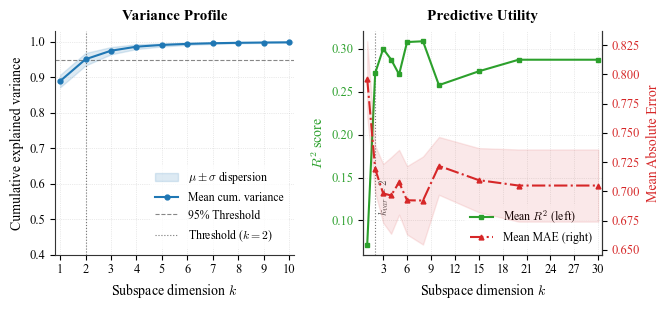

In [22]:
plot_grassmann_justification(
    variance_df,
    regression_df,
    save_path="/Users/karlfindhansen/Desktop/thesis figures/grassmann/grassmann_k_justification.png",
)

In [25]:
regression_df.head(10)

k,Mean MAE,Std MAE,Mean R²
i64,f64,f64,f64
1,0.7958,0.0324,0.0719
2,0.7191,0.02,0.2717
3,0.6983,0.0251,0.3
4,0.6965,0.0327,0.2875
5,0.7078,0.0277,0.2702
6,0.6924,0.0292,0.3079
8,0.6922,0.0376,0.3088
10,0.7218,0.0247,0.2577
15,0.7096,0.0274,0.2738
